Step 1: Load the trained score model and compute SHAP values for a background sample.

In [1]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

model = joblib.load('models/score_model.pkl')
score_data = pd.read_csv('data/processed/score_features.csv')

feature_cols_score = ['current_score', 'current_wickets', 'current_run_rate',
                       'runs_last_24balls', 'balls_remaining']

X = score_data[feature_cols_score]

# SHAP needs a background sample for efficiency - use a random subset, not the full 223k rows
X_sample = X.sample(500, random_state=42)

explainer = shap.LinearExplainer(model, X_sample)
shap_values = explainer(X_sample)

print("SHAP values shape:", shap_values.values.shape)

C:\Users\ramha.LAPTOP-AB00D4P2\AppData\Local\Temp\ipykernel_23572\2838163440.py:7: DtypeWarning: Columns (0: season, 1: non_boundary, 2: fielder_2, 3: fielder_3) have mixed types. Specify dtype option on import or set low_memory=False.
  score_data = pd.read_csv('data/processed/score_features.csv')
Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


SHAP values shape: (500, 5)


Step 2: Plot the global SHAP summary showing overall feature importance.

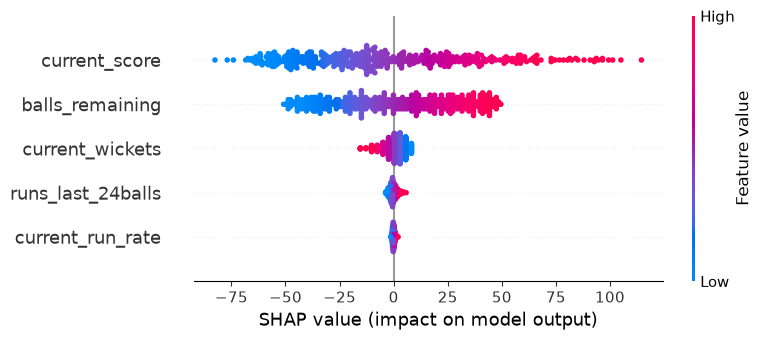

In [2]:
shap.summary_plot(shap_values, X_sample, show=True)

Step 3: Local explanation (one specific prediction, explained in plain English)

c:\Users\ramha.LAPTOP-AB00D4P2\OneDrive\Desktop\Data Science\IPL_DataScience_Project\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Match state:
current_score        123.000000
current_wickets        0.000000
current_run_rate       8.581395
runs_last_24balls     40.000000
balls_remaining       34.000000
Name: 33497, dtype: float64

Model predicted final score: 185
Actual final score was: 184


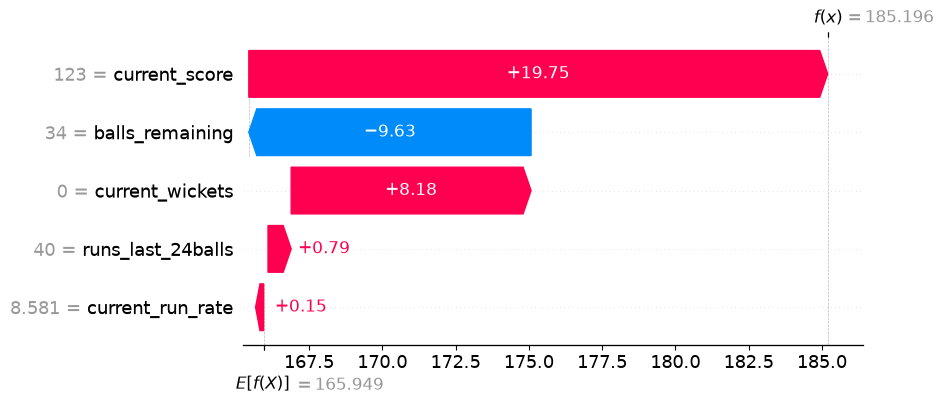

In [3]:
# pick one specific match snapshot to explain
sample_idx = 250
row = X_sample.iloc[sample_idx]
actual_final = score_data.loc[X_sample.index[sample_idx], 'final_score']
predicted = model.predict(row.values.reshape(1, -1))[0]

print("Match state:")
print(row)
print(f"\nModel predicted final score: {predicted:.0f}")
print(f"Actual final score was: {actual_final}")

# SHAP explanation for THIS ONE prediction
shap.plots.waterfall(shap_values[sample_idx], show=True)

Step 4 — Turn this into a plain-English function (this is what your router will call later)

In [4]:
def explain_score_prediction(row, shap_row, predicted, feature_names):
    contributions = list(zip(feature_names, shap_row.values))
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    
    explanation = f"Predicted final score: {predicted:.0f} runs.\n\nKey factors:\n"
    for feat, val in contributions[:3]:
        direction = "increased" if val > 0 else "decreased"
        explanation += f"- {feat} = {row[feat]:.1f} → {direction} the prediction by {abs(val):.1f} runs\n"
    return explanation

print(explain_score_prediction(row, shap_values[sample_idx], predicted, feature_cols_score))

Predicted final score: 185 runs.

Key factors:
- current_score = 123.0 → increased the prediction by 19.8 runs
- balls_remaining = 34.0 → decreased the prediction by 9.6 runs
- current_wickets = 0.0 → increased the prediction by 8.2 runs

